## 6 — Modeling Improvement and Tuning (Sprint 4)

### Sprint objective
Improve the Sprint 3 MVP modeling results by adding **careful hyperparameter tuning**, stronger **stability/overfitting diagnostics**, and **thesis-ready result figures**.

This notebook is **self-contained** and compares:
- **Base dataset**: `datasets/model_ready_crime_nbh_2024.csv`
- **Spatial dataset**: `datasets/spatial_dataset_crime_nbh_2024.csv`

Models:
1. Linear Regression baseline
2. Random Forest
3. XGBoost

Key thesis constraints:
- Leakage-aware feature selection (no target/near-target columns, no target lags/spillovers)
- Leakage-safe preprocessing inside sklearn pipelines
- 5-fold CV (GroupKFold preferred if municipality column exists)
- Fold-level train vs validation metrics


## 2. Imports and reproducibility settings


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [2]:
# Optional: XGBoost import
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = repr(e)

print("XGBoost available:", XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print("XGBoost import error:", XGBOOST_IMPORT_ERROR)
    print("\nIf this is a libomp/OpenMP issue on macOS, fix that first (see Sprint notes), then restart kernel.")


XGBoost available: True


In [3]:
# Package versions (reproducibility)
try:
    from importlib.metadata import version
except Exception:
    from importlib_metadata import version  # type: ignore

pkgs = ["numpy", "pandas", "scikit-learn", "xgboost"]
versions = {}
for p in pkgs:
    try:
        versions[p] = version(p)
    except Exception:
        versions[p] = None
print(json.dumps(versions, indent=2))


{
  "numpy": "1.26.4",
  "pandas": "2.3.3",
  "scikit-learn": "1.8.0",
  "xgboost": "3.2.0"
}


## 3. Load base and spatial datasets


In [4]:
DATA_DIR = Path("datasets")
OUT_DIR = Path("outputs") / "modeling_improvement"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

BASE_PATH = DATA_DIR / "model_ready_crime_nbh_2024.csv"
SPATIAL_PATH = DATA_DIR / "spatial_dataset_crime_nbh_2024.csv"

base_df = pd.read_csv(BASE_PATH, low_memory=False)
spatial_df = pd.read_csv(SPATIAL_PATH, low_memory=False)

print("base_df shape:", base_df.shape)
print("spatial_df shape:", spatial_df.shape)
print("\nbase first 10 columns:", base_df.columns[:10].tolist())
print("spatial first 10 columns:", spatial_df.columns[:10].tolist())


base_df shape: (14019, 106)
spatial_df shape: (14019, 116)

base first 10 columns: ['gwb_code_10', 'gwb_code_8', 'regio', 'gm_naam', 'recs', 'gwb_code', 'ind_wbi', 'a_inw', 'a_man', 'a_vrouw']
spatial first 10 columns: ['gwb_code_10', 'gwb_code_8', 'regio', 'gm_naam', 'recs', 'gwb_code', 'ind_wbi', 'a_inw', 'a_man', 'a_vrouw']


## 4. Detect target, ID, grouping, and leakage columns


Base target detected: log_crime_count
Spatial target detected: log_crime_count

Chosen target column: log_crime_count

=== Exclusion report: base ===
Target: log_crime_count
Group col: gm_naam
ID-like cols: ['gwb_code_10', 'gwb_code_8', 'regio', 'gwb_code', 'merge_key', 'ID', 'centroid_x', 'centroid_y']
Leakage-like cols: []

=== Exclusion report: spatial ===
Target: log_crime_count
Group col: gm_naam
ID-like cols: ['gwb_code_10', 'gwb_code_8', 'regio', 'gwb_code', 'merge_key', 'ID', 'centroid_x', 'centroid_y']
Leakage-like cols: []

Target stats:
count    14019.000000
mean         3.135936
std          1.376612
min          0.000000
25%          2.197225
50%          3.178054
75%          4.077537
max          8.220134


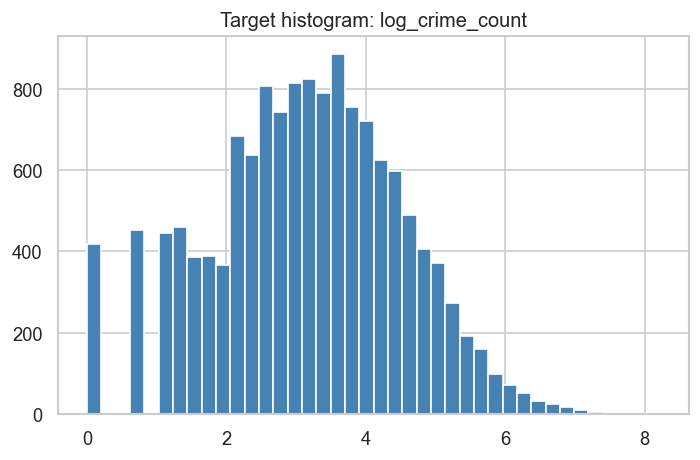

In [5]:
TARGET_PREFERENCE = [
    "log_crime_rate",
    "y_log_crime_rate_per_1k",
    "log_crime_count",
    "y_log_crime_count",
]

# Raw/near-target columns that must not be used as predictors
RAW_TARGET_LIKE = {
    "crime_count",
    "crime_rate_per_1000",
    "population",
    "population_zero",
    "GeregistreerdeMisdrijven_1",
    "a_inw",
}

ID_COL_HINTS = ["gwb_code", "buurt", "wijk", "code", "id", "regio", "merge_key"]
GROUP_COL_CANDIDATES = ["gm_naam", "gm_code", "gemeente", "municipality", "municipality_code"]

# Leakage patterns: ban target-derived lags/spillovers; allow exogenous queen_lag_* later explicitly
LEAKAGE_PATTERNS = [
    r"spillover_spec",
    r"spillover_target",
    r"target_lag",
    r"lag_y",
    r"spillover_lag",
    r"lag_.*crime",
    r"crime.*lag",
]
LEAKAGE_REGEX = re.compile("|".join(LEAKAGE_PATTERNS), flags=re.IGNORECASE)

# Additional hard bans for predictors (except queen_lag_* allowed)
BANNED_PRED_REGEX = re.compile(r"(^y_)|(^log_crime)|(^crime_)|crime_rate|misdrijf", flags=re.IGNORECASE)


def choose_target(df: pd.DataFrame) -> str:
    for t in TARGET_PREFERENCE:
        if t in df.columns:
            return t
    raise ValueError(f"No preferred target found. Expected one of {TARGET_PREFERENCE}")


def detect_group_col(df: pd.DataFrame) -> Optional[str]:
    for c in GROUP_COL_CANDIDATES:
        if c in df.columns:
            return c
    return None


def detect_id_cols(df: pd.DataFrame) -> List[str]:
    out = []
    for c in df.columns:
        cl = c.lower()
        if any(h in cl for h in ID_COL_HINTS):
            out.append(c)
    # explicit ids
    for c in ["gwb_code_10", "buurtcode", "ID"]:
        if c in df.columns and c not in out:
            out.append(c)
    return out


def find_leakage_cols(df: pd.DataFrame) -> List[str]:
    return [c for c in df.columns if LEAKAGE_REGEX.search(c)]


def print_exclusion_report(df: pd.DataFrame, target: str, id_cols: List[str], group_col: Optional[str]):
    leak = find_leakage_cols(df)
    print("Target:", target)
    print("Group col:", group_col)
    print("ID-like cols:", id_cols)
    print("Leakage-like cols:", leak)

base_target = choose_target(base_df)
spatial_target = choose_target(spatial_df)

print("Base target detected:", base_target)
print("Spatial target detected:", spatial_target)

# Use a single target name for both datasets if needed by aliasing
# Prefer the first available in the preference list across BOTH.
for t in TARGET_PREFERENCE:
    if t in base_df.columns and t in spatial_df.columns:
        TARGET_COL = t
        break
else:
    # allow equivalence: log_crime_rate vs y_log_crime_rate_per_1k and log_crime_count vs y_log_crime_count
    if ("log_crime_rate" in spatial_df.columns) and ("y_log_crime_rate_per_1k" in base_df.columns):
        base_df["log_crime_rate"] = base_df["y_log_crime_rate_per_1k"]
        TARGET_COL = "log_crime_rate"
        print("Aliased base y_log_crime_rate_per_1k -> log_crime_rate")
    elif ("log_crime_count" in spatial_df.columns) and ("y_log_crime_count" in base_df.columns):
        base_df["log_crime_count"] = base_df["y_log_crime_count"]
        TARGET_COL = "log_crime_count"
        print("Aliased base y_log_crime_count -> log_crime_count")
    elif ("log_crime_rate" in base_df.columns) and ("y_log_crime_rate_per_1k" in spatial_df.columns):
        spatial_df["log_crime_rate"] = spatial_df["y_log_crime_rate_per_1k"]
        TARGET_COL = "log_crime_rate"
        print("Aliased spatial y_log_crime_rate_per_1k -> log_crime_rate")
    elif ("log_crime_count" in base_df.columns) and ("y_log_crime_count" in spatial_df.columns):
        spatial_df["log_crime_count"] = spatial_df["y_log_crime_count"]
        TARGET_COL = "log_crime_count"
        print("Aliased spatial y_log_crime_count -> log_crime_count")
    else:
        raise ValueError("No common target found across base and spatial datasets.")

print("\nChosen target column:", TARGET_COL)

GROUP_COL = detect_group_col(base_df) or detect_group_col(spatial_df)
ID_COLS_BASE = detect_id_cols(base_df)
ID_COLS_SPATIAL = detect_id_cols(spatial_df)

print("\n=== Exclusion report: base ===")
print_exclusion_report(base_df, TARGET_COL, ID_COLS_BASE, GROUP_COL)
print("\n=== Exclusion report: spatial ===")
print_exclusion_report(spatial_df, TARGET_COL, ID_COLS_SPATIAL, GROUP_COL)

print("\nTarget stats:")
print(base_df[TARGET_COL].describe().to_string())
plt.figure(figsize=(6,4))
plt.hist(base_df[TARGET_COL].dropna(), bins=40, color='steelblue', edgecolor='white')
plt.title(f"Target histogram: {TARGET_COL}")
plt.tight_layout()
plt.savefig(FIG_DIR / f"target_hist_{TARGET_COL}.png")
plt.show()


## 5. Define feature matrices


In [6]:
def select_numeric_predictors(df: pd.DataFrame, target: str, id_cols: List[str]) -> Tuple[pd.DataFrame, pd.Series, Dict[str, Any]]:
    df = df.copy()

    # Exclude ID, target, raw target-like, and leakage columns
    leak = find_leakage_cols(df)
    exclude = set(id_cols) | set(leak) | set(RAW_TARGET_LIKE) | set(TARGET_PREFERENCE) | {target}

    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    feature_cols = [c for c in num_cols if c not in exclude]

    # Allow queen_lag_* spillovers, but ban target-like patterns in predictors
    banned = []
    for c in feature_cols:
        if c.startswith('queen_lag_'):
            continue
        if BANNED_PRED_REGEX.search(c):
            banned.append(c)

    if banned:
        print("WARNING: dropping banned predictor columns (target-like naming):", banned[:30])
        feature_cols = [c for c in feature_cols if c not in banned]

    X = df[feature_cols].copy()
    y = df[target].copy()

    # Strong leakage assertions
    assert target not in X.columns
    assert not any(LEAKAGE_REGEX.search(c) for c in X.columns)
    assert not any(c.lower().startswith('y_') for c in X.columns)

    # Extra guard: remove any feature that exactly duplicates y
    dup_like = []
    for c in feature_cols:
        try:
            if y.equals(df[c]):
                dup_like.append(c)
        except Exception:
            pass
    if dup_like:
        raise ValueError(f"Leakage detected: feature(s) exactly equal to target: {dup_like}")

    info = {
        'n_features': len(feature_cols),
        'spillover_cols': [c for c in feature_cols if c.startswith('queen_lag_')],
        'excluded_id_cols': id_cols,
        'excluded_leakage_cols': leak,
        'banned_removed': banned,
    }
    return X, y, info

X_base, y_base, info_base = select_numeric_predictors(base_df, TARGET_COL, ID_COLS_BASE)
X_spatial, y_spatial, info_spatial = select_numeric_predictors(spatial_df, TARGET_COL, ID_COLS_SPATIAL)

print('Base X shape:', X_base.shape)
print('Spatial X shape:', X_spatial.shape)
print('Spillover columns (spatial):', len(info_spatial['spillover_cols']))
print(info_spatial['spillover_cols'][:40])


Base X shape: (14019, 84)
Spatial X shape: (14019, 94)
Spillover columns (spatial): 10
['queen_lag_sum_pop_density_per_km2', 'queen_lag_mean_pop_density_per_km2', 'queen_lag_sum_ste_oad', 'queen_lag_mean_ste_oad', 'queen_lag_sum_p_huurw', 'queen_lag_mean_p_huurw', 'queen_lag_sum_g_pau_km', 'queen_lag_mean_g_pau_km', 'queen_lag_sum_g_pau_hh', 'queen_lag_mean_g_pau_hh']


## 6. Define validation strategy


In [7]:
def make_cv(groups: Optional[pd.Series]):
    if groups is not None:
        return GroupKFold(n_splits=5), f"GroupKFold(5) on '{groups.name}'"
    print('WARNING: No group column found; using KFold instead of GroupKFold.')
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), 'KFold(5, shuffle=True, random_state=42)'


def fold_diagnostics(cv, X, y, groups):
    sizes = []
    for i,(tr,va) in enumerate(cv.split(X,y,groups)):
        sizes.append((len(tr),len(va)))
        if groups is not None:
            ov = set(groups.iloc[tr].astype(str)).intersection(set(groups.iloc[va].astype(str)))
            if ov:
                raise ValueError('Group overlap detected')
    return sizes

groups_base = base_df[GROUP_COL] if GROUP_COL and GROUP_COL in base_df.columns else None
groups_spatial = spatial_df[GROUP_COL] if GROUP_COL and GROUP_COL in spatial_df.columns else None

cv_base, cv_desc_base = make_cv(groups_base)
cv_spatial, cv_desc_spatial = make_cv(groups_spatial)

print('Base CV:', cv_desc_base)
print('Fold sizes:', fold_diagnostics(cv_base, X_base, y_base, groups_base))

print('\nSpatial CV:', cv_desc_spatial)
print('Fold sizes:', fold_diagnostics(cv_spatial, X_spatial, y_spatial, groups_spatial))


Base CV: GroupKFold(5) on 'gm_naam'
Fold sizes: [(11215, 2804), (11215, 2804), (11215, 2804), (11215, 2804), (11216, 2803)]

Spatial CV: GroupKFold(5) on 'gm_naam'
Fold sizes: [(11215, 2804), (11215, 2804), (11215, 2804), (11215, 2804), (11216, 2803)]


## Helper functions for fold-by-fold evaluation


In [8]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def eval_foldwise(model: Pipeline, X: pd.DataFrame, y: pd.Series, cv, groups: Optional[pd.Series], tag: Dict[str,str], context: pd.DataFrame):
    oof = np.full(len(y), np.nan)
    rows = []

    for fold,(tr,va) in enumerate(cv.split(X,y,groups)):
        m = Pipeline(steps=model.steps)
        m.fit(X.iloc[tr], y.iloc[tr])

        p_tr = m.predict(X.iloc[tr])
        p_va = m.predict(X.iloc[va])
        oof[va] = p_va

        rows.append({
            **tag,
            'fold': fold,
            'n_train': len(tr),
            'n_val': len(va),
            'rmse_train': rmse(y.iloc[tr], p_tr),
            'rmse_val': rmse(y.iloc[va], p_va),
            'mae_train': float(mean_absolute_error(y.iloc[tr], p_tr)),
            'mae_val': float(mean_absolute_error(y.iloc[va], p_va)),
            'r2_train': float(r2_score(y.iloc[tr], p_tr)),
            'r2_val': float(r2_score(y.iloc[va], p_va)),
        })

    fold_df = pd.DataFrame(rows)

    oof_df = context.copy()
    oof_df['dataset_type'] = tag['dataset_type']
    oof_df['model'] = tag['model']
    oof_df['tuning_status'] = tag['tuning_status']
    oof_df['y_true'] = y.values
    oof_df['y_pred_oof'] = oof
    oof_df['residual'] = oof_df['y_true'] - oof_df['y_pred_oof']
    oof_df['abs_error'] = oof_df['residual'].abs()

    if np.isnan(oof).any():
        raise RuntimeError('OOF contains NaN')

    return fold_df, oof_df


def summarize_models(fold_metrics: pd.DataFrame) -> pd.DataFrame:
    g = fold_metrics.groupby(['model','dataset_type','tuning_status'])
    out = g.agg(
        mean_train_RMSE=('rmse_train','mean'),
        mean_val_RMSE=('rmse_val','mean'),
        std_val_RMSE=('rmse_val','std'),
        mean_val_MAE=('mae_val','mean'),
        std_val_MAE=('mae_val','std'),
        mean_val_R2=('r2_val','mean'),
        std_val_R2=('r2_val','std'),
    ).reset_index()
    out['overfit_gap_RMSE'] = out['mean_val_RMSE'] - out['mean_train_RMSE']
    return out.sort_values(['dataset_type','mean_val_RMSE'])


## 7. Recreate MVP baseline performance


In [9]:
def pipe_ols():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LinearRegression()),
    ])


def pipe_rf_mvp():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])


def pipe_xgb_mvp():
    if not XGBOOST_AVAILABLE:
        raise ImportError(f"XGBoost unavailable: {XGBOOST_IMPORT_ERROR}")
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', xgb.XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective='reg:squarederror',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

KEEP_CTX = [c for c in ['gwb_code_10','gm_naam','population','crime_count'] if c in base_df.columns]
ctx_base = base_df[KEEP_CTX].copy() if KEEP_CTX else pd.DataFrame(index=base_df.index)
ctx_spatial = spatial_df[KEEP_CTX].copy() if KEEP_CTX else pd.DataFrame(index=spatial_df.index)

fold_tables = []
oof_tables = []

for dataset_type,(X,y,cv,groups,ctx) in {
    'base': (X_base,y_base,cv_base,groups_base,ctx_base),
    'spatial': (X_spatial,y_spatial,cv_spatial,groups_spatial,ctx_spatial),
}.items():
    # OLS
    f,o = eval_foldwise(pipe_ols(), X,y,cv,groups, {'model':'OLS','dataset_type':dataset_type,'tuning_status':'mvp'}, ctx)
    fold_tables.append(f); oof_tables.append(o)

    # RF MVP
    f,o = eval_foldwise(pipe_rf_mvp(), X,y,cv,groups, {'model':'RF','dataset_type':dataset_type,'tuning_status':'mvp'}, ctx)
    fold_tables.append(f); oof_tables.append(o)

    # XGB MVP
    if XGBOOST_AVAILABLE:
        f,o = eval_foldwise(pipe_xgb_mvp(), X,y,cv,groups, {'model':'XGB','dataset_type':dataset_type,'tuning_status':'mvp'}, ctx)
        fold_tables.append(f); oof_tables.append(o)

fold_metrics_mvp = pd.concat(fold_tables, ignore_index=True)
oof_mvp = pd.concat(oof_tables, ignore_index=True)

mvp_summary = summarize_models(fold_metrics_mvp)
print(mvp_summary.to_string(index=False))


model dataset_type tuning_status  mean_train_RMSE  mean_val_RMSE  std_val_RMSE  mean_val_MAE  std_val_MAE  mean_val_R2  std_val_R2  overfit_gap_RMSE
  XGB         base           mvp         0.267551       0.558190      0.006422      0.407695     0.001869     0.832552    0.008373          0.290639
   RF         base           mvp         0.241610       0.581426      0.006628      0.423856     0.004860     0.818357    0.008059          0.339816
  OLS         base           mvp         0.674993       0.699105      0.032490      0.517597     0.010448     0.736824    0.028307          0.024113
  XGB      spatial           mvp         0.256041       0.549445      0.006753      0.403967     0.006765     0.837797    0.007069          0.293404
   RF      spatial           mvp         0.236184       0.570915      0.007414      0.419391     0.006485     0.824894    0.007009          0.334732
  OLS      spatial           mvp         0.649769       0.674956      0.032320      0.502304     0.013226 

## 8. Hyperparameter tuning setup

**Why RandomizedSearchCV?**

Random Forest and XGBoost contain multiple interacting hyperparameters. A full grid search would be computationally expensive, while randomized search allows broader coverage of plausible parameter values within the available thesis sprint time.

Tuning uses the **same cross-validation strategy** as model evaluation.
Primary tuning metric: **negative RMSE**.


## 9. Tune Random Forest


In [14]:
rf_param_grid = {
    'model__n_estimators': [300, 500, 800],
    'model__max_depth': [None, 10, 20, 40],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 5, 10],
    'model__max_features': ['sqrt', 'log2', 0.5, 0.8],
    'model__bootstrap': [True],
}


def tune_rf(X, y, cv, groups, dataset_tag: str):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=rf_param_grid,
        n_iter=30,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=1,
        random_state=RANDOM_STATE,
        verbose=1,
        return_train_score=True,
    )

    search.fit(X, y, **({'groups': groups} if groups is not None else {}))
    res = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
    res.to_csv(OUT_DIR / f"tuning_results_rf_{dataset_tag}.csv", index=False)

    print('Best RF params', dataset_tag, ':', search.best_params_)
    print('Best RF CV neg-RMSE', dataset_tag, ':', search.best_score_)

    return search.best_estimator_, res

rf_best_base, rf_res_base = tune_rf(X_base, y_base, cv_base, groups_base, 'base')
rf_best_spatial, rf_res_spatial = tune_rf(X_spatial, y_spatial, cv_spatial, groups_spatial, 'spatial')


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF params base : {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None, 'model__bootstrap': True}
Best RF CV neg-RMSE base : -0.5728367268885262
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RF params spatial : {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None, 'model__bootstrap': True}
Best RF CV neg-RMSE spatial : -0.5624403145833992


In [15]:
# Winning Hyperparameters based on tuning 5 folds for each of 30 candidates, totalling 150 fits

# Best RF params base : {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None, 'model__bootstrap': True}
# Best RF CV neg-RMSE base : -0.5728367268885262
# Best RF params spatial : {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None, 'model__bootstrap': True}
# Best RF CV neg-RMSE spatial : -0.5624403145833992

## 10. Tune XGBoost


In [16]:
if not XGBOOST_AVAILABLE:
    raise ImportError(f"XGBoost unavailable; cannot run XGB tuning. Error: {XGBOOST_IMPORT_ERROR}")

xgb_param_grid = {
    'model__n_estimators': [300, 500, 800, 1000],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [3, 4, 5, 6, 8],
    'model__min_child_weight': [1, 3, 5, 10],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [0.5, 1, 2, 5],
}


def tune_xgb(X, y, cv, groups, dataset_tag: str):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=xgb_param_grid,
        n_iter=40,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
        return_train_score=True,
    )

    search.fit(X, y, **({'groups': groups} if groups is not None else {}))
    res = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
    res.to_csv(OUT_DIR / f"tuning_results_xgb_{dataset_tag}.csv", index=False)

    print('Best XGB params', dataset_tag, ':', search.best_params_)
    print('Best XGB CV neg-RMSE', dataset_tag, ':', search.best_score_)

    return search.best_estimator_, res

xgb_best_base, xgb_res_base = tune_xgb(X_base, y_base, cv_base, groups_base, 'base')
xgb_best_spatial, xgb_res_spatial = tune_xgb(X_spatial, y_spatial, cv_spatial, groups_spatial, 'spatial')


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB params base : {'model__subsample': 0.6, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.01, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}
Best XGB CV neg-RMSE base : -0.5550307454773236
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB params spatial : {'model__subsample': 0.6, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.01, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}
Best XGB CV neg-RMSE spatial : -0.5449436516094361


In [17]:
# Fitting 5 folds for each of 40 candidates, totalling 200 fits

# Best XGB params base : {'model__subsample': 0.6, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.01, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}
# Best XGB CV neg-RMSE base : -0.5550307454773236

# Best XGB params spatial : {'model__subsample': 0.6, 'model__reg_lambda': 0.5, 'model__reg_alpha': 0.01, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.6}
# Best XGB CV neg-RMSE spatial : -0.5449436516094361

## 11–12. Compare untuned vs tuned models and base vs spatial


In [18]:
fold_tables = []
oof_tables = []

# OLS (no tuning)
for dataset_type,(X,y,cv,groups,ctx) in {
    'base': (X_base,y_base,cv_base,groups_base,ctx_base),
    'spatial': (X_spatial,y_spatial,cv_spatial,groups_spatial,ctx_spatial),
}.items():
    f,o = eval_foldwise(pipe_ols(), X,y,cv,groups, {'model':'OLS','dataset_type':dataset_type,'tuning_status':'baseline'}, ctx)
    fold_tables.append(f); oof_tables.append(o)

# RF MVP + tuned
for dataset_type,(X,y,cv,groups,ctx,rf_best) in {
    'base': (X_base,y_base,cv_base,groups_base,ctx_base,rf_best_base),
    'spatial': (X_spatial,y_spatial,cv_spatial,groups_spatial,ctx_spatial,rf_best_spatial),
}.items():
    f,o = eval_foldwise(pipe_rf_mvp(), X,y,cv,groups, {'model':'RF','dataset_type':dataset_type,'tuning_status':'mvp'}, ctx)
    fold_tables.append(f); oof_tables.append(o)

    f,o = eval_foldwise(rf_best, X,y,cv,groups, {'model':'RF','dataset_type':dataset_type,'tuning_status':'tuned'}, ctx)
    fold_tables.append(f); oof_tables.append(o)

# XGB MVP + tuned
for dataset_type,(X,y,cv,groups,ctx,xgb_best) in {
    'base': (X_base,y_base,cv_base,groups_base,ctx_base,xgb_best_base),
    'spatial': (X_spatial,y_spatial,cv_spatial,groups_spatial,ctx_spatial,xgb_best_spatial),
}.items():
    f,o = eval_foldwise(pipe_xgb_mvp(), X,y,cv,groups, {'model':'XGB','dataset_type':dataset_type,'tuning_status':'mvp'}, ctx)
    fold_tables.append(f); oof_tables.append(o)

    f,o = eval_foldwise(xgb_best, X,y,cv,groups, {'model':'XGB','dataset_type':dataset_type,'tuning_status':'tuned'}, ctx)
    fold_tables.append(f); oof_tables.append(o)

fold_level_metrics = pd.concat(fold_tables, ignore_index=True)
oof_all = pd.concat(oof_tables, ignore_index=True)

final_comparison = summarize_models(fold_level_metrics)
final_comparison.to_csv(OUT_DIR / 'final_model_comparison.csv', index=False)
fold_level_metrics.to_csv(OUT_DIR / 'fold_level_metrics.csv', index=False)

print(final_comparison.to_string(index=False))


model dataset_type tuning_status  mean_train_RMSE  mean_val_RMSE  std_val_RMSE  mean_val_MAE  std_val_MAE  mean_val_R2  std_val_R2  overfit_gap_RMSE
  XGB         base         tuned         0.348198       0.555031      0.005441      0.405962     0.002926     0.834407    0.009058          0.206833
  XGB         base           mvp         0.267551       0.558190      0.006422      0.407695     0.001869     0.832552    0.008373          0.290639
   RF         base         tuned         0.208658       0.572837      0.005909      0.417954     0.005076     0.823629    0.009176          0.364179
   RF         base           mvp         0.241610       0.581426      0.006628      0.423856     0.004860     0.818357    0.008059          0.339816
  OLS         base      baseline         0.674993       0.699105      0.032490      0.517597     0.010448     0.736824    0.028307          0.024113
  XGB      spatial         tuned         0.336970       0.544944      0.004216      0.401852     0.003983 

## 13. Overfitting and fold stability analysis


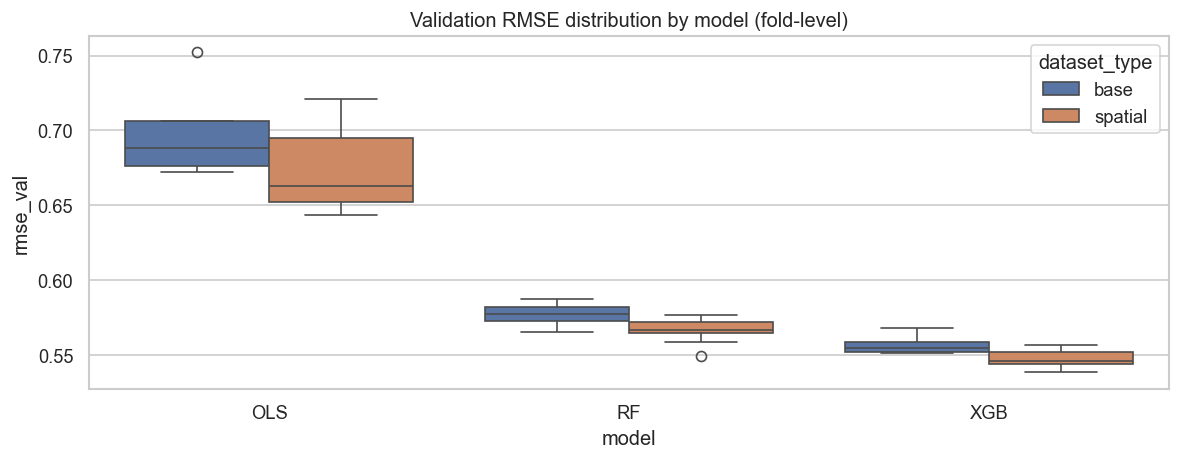

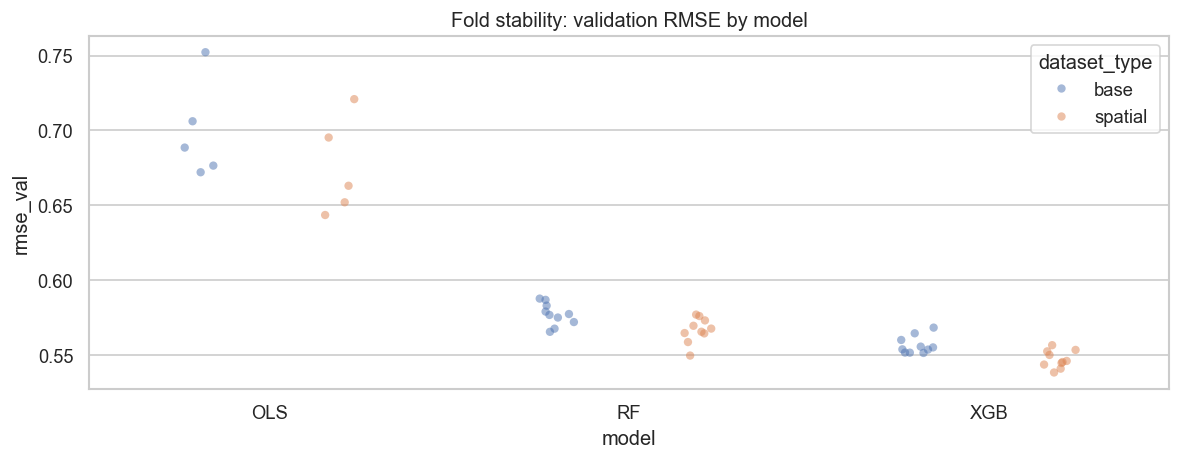

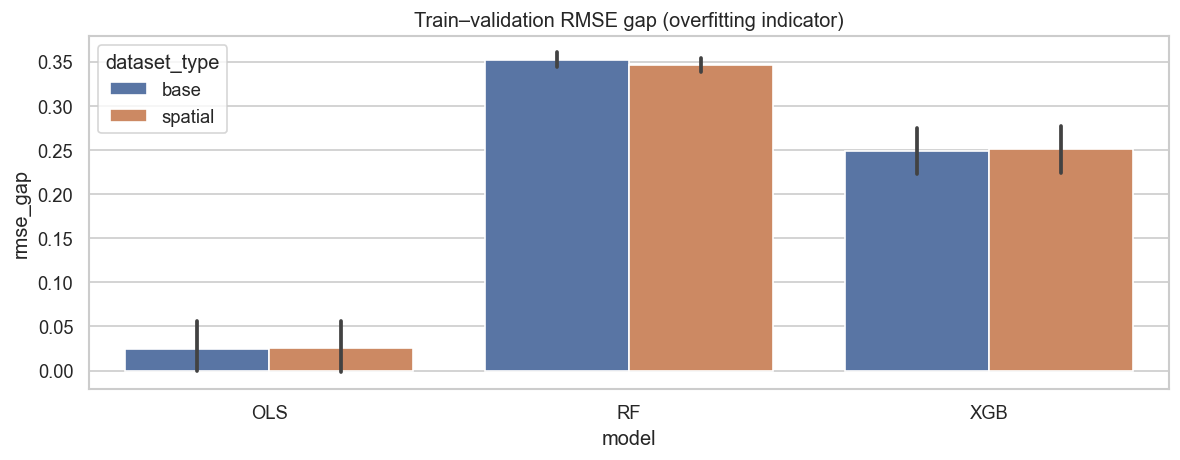

In [19]:
plt.figure(figsize=(10,4))
sns.boxplot(data=fold_level_metrics, x='model', y='rmse_val', hue='dataset_type')
plt.title('Validation RMSE distribution by model (fold-level)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fold_rmse_boxplot.png')
plt.show()

plt.figure(figsize=(10,4))
sns.stripplot(data=fold_level_metrics, x='model', y='rmse_val', hue='dataset_type', dodge=True, alpha=0.5)
plt.title('Fold stability: validation RMSE by model')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fold_rmse_stripplot.png')
plt.show()

# Train vs validation RMSE
fold_level_metrics['rmse_gap'] = fold_level_metrics['rmse_val'] - fold_level_metrics['rmse_train']
plt.figure(figsize=(10,4))
sns.barplot(data=fold_level_metrics, x='model', y='rmse_gap', hue='dataset_type')
plt.title('Train–validation RMSE gap (overfitting indicator)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'train_val_rmse_gap.png')
plt.show()


## 14. Error analysis and failure modes (best model)


Best model: XGB dataset: spatial tuning: tuned


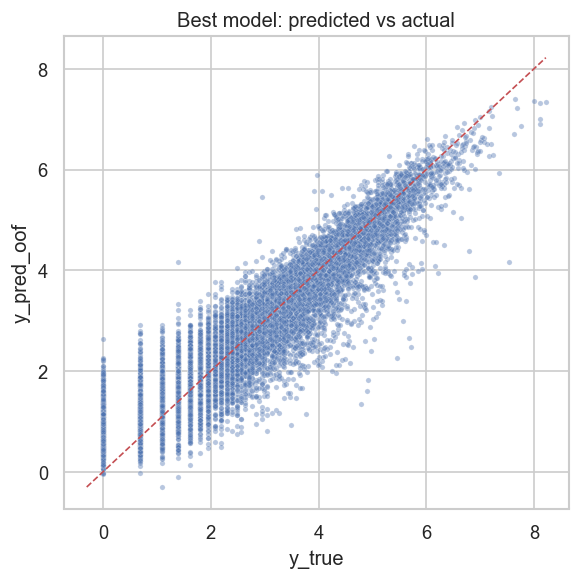

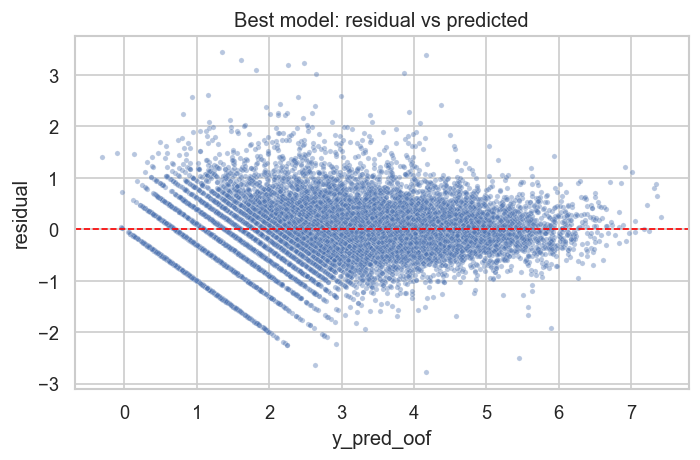

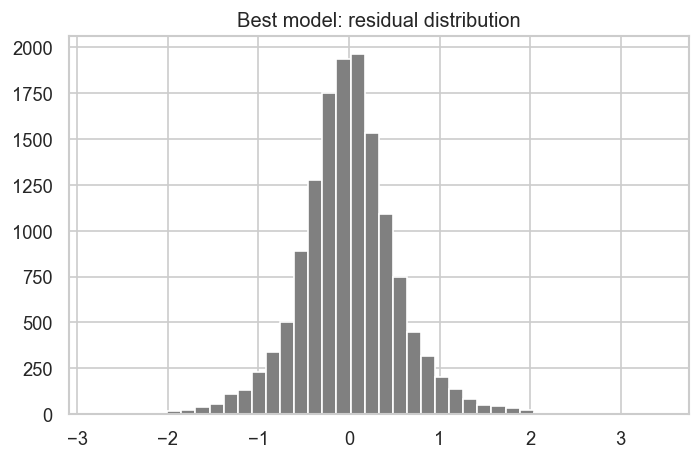


Top 20 absolute errors:
gwb_code_10             gm_naam  population  crime_count   y_true  y_pred_oof  abs_error
 BU19040205      Stichtse Vecht        50.0        120.0 4.795791    1.354741   3.441050
 BU0363AD01           Amsterdam         5.0       1882.0 7.540622    4.158550   3.382072
 BU03562300          Nieuwegein        30.0        133.0 4.897840    1.608018   3.289822
 BU19010405 Bodegraven-Reeuwijk       375.0        303.0 5.717028    2.484515   3.232513
 BU19040201      Stichtse Vecht       150.0        234.0 5.459586    2.264810   3.194776
 BU02286001                 Ede       215.0        136.0 4.919981    1.815026   3.104955
 BU06060003            Schiedam       770.0        996.0 6.904751    3.863394   3.041357
 BU07580506               Breda        55.0        290.0 5.673323    2.651093   3.022231
 BU02850101              Voorst      4230.0          3.0 1.386294    4.170190   2.783896
 BU04820601        Alblasserdam         5.0          0.0 0.000000    2.635326   2.635

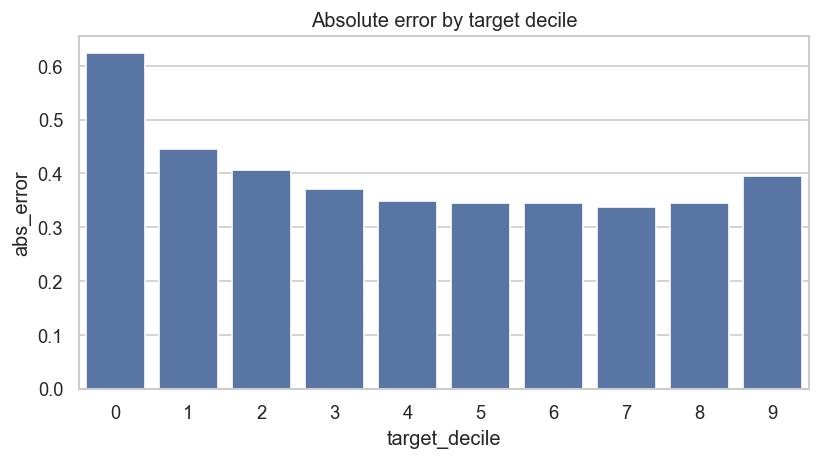

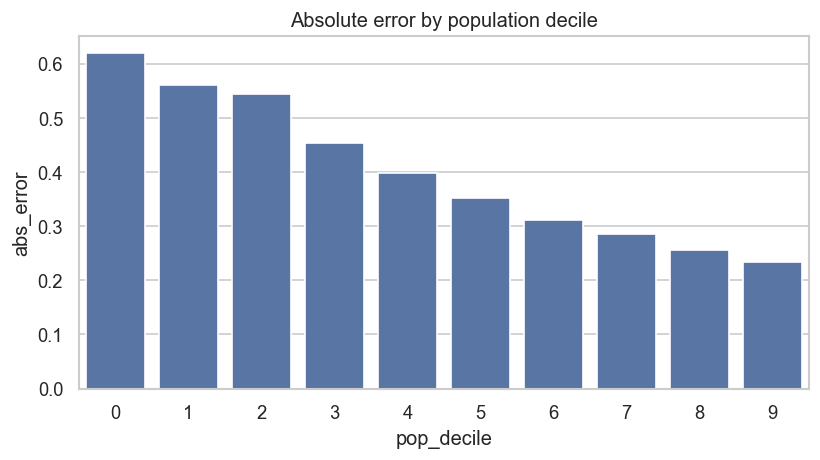


Interpretation prompts:
- Underprediction in high target deciles?
- Errors concentrated in low-population neighborhoods?
- Does spatial feature set help certain deciles/groups?


In [20]:
# Select best model by mean validation RMSE
best_row = final_comparison.sort_values('mean_val_RMSE').iloc[0]
BEST_MODEL = best_row['model']
BEST_DATASET = best_row['dataset_type']
BEST_TUNING = best_row['tuning_status']

print('Best model:', BEST_MODEL, 'dataset:', BEST_DATASET, 'tuning:', BEST_TUNING)

best_oof = oof_all[(oof_all['model']==BEST_MODEL) & (oof_all['dataset_type']==BEST_DATASET) & (oof_all['tuning_status']==BEST_TUNING)].copy()
best_oof.to_csv(OUT_DIR / 'oof_predictions_best_model.csv', index=False)

# plots
plt.figure(figsize=(5,5))
sns.scatterplot(x=best_oof['y_true'], y=best_oof['y_pred_oof'], s=10, alpha=0.4)
mn = min(best_oof['y_true'].min(), best_oof['y_pred_oof'].min())
mx = max(best_oof['y_true'].max(), best_oof['y_pred_oof'].max())
plt.plot([mn,mx],[mn,mx],'r--',lw=1)
plt.title('Best model: predicted vs actual')
plt.tight_layout()
plt.savefig(FIG_DIR / 'best_pred_vs_actual.png')
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=best_oof['y_pred_oof'], y=best_oof['residual'], s=10, alpha=0.4)
plt.axhline(0, color='red', ls='--', lw=1)
plt.title('Best model: residual vs predicted')
plt.tight_layout()
plt.savefig(FIG_DIR / 'best_residual_vs_pred.png')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(best_oof['residual'], bins=40, color='gray', edgecolor='white')
plt.title('Best model: residual distribution')
plt.tight_layout()
plt.savefig(FIG_DIR / 'best_residual_hist.png')
plt.show()

# top errors
top20 = best_oof.sort_values('abs_error', ascending=False).head(20)
err_cols = [c for c in ['gwb_code_10','gm_naam','population','crime_count'] if c in top20.columns] + ['y_true','y_pred_oof','abs_error']
print('\nTop 20 absolute errors:')
print(top20[err_cols].to_string(index=False))

# error by target decile
best_oof['target_decile'] = pd.qcut(best_oof['y_true'], 10, labels=False, duplicates='drop')
by_dec = best_oof.groupby('target_decile')['abs_error'].mean().reset_index()
by_dec.to_csv(OUT_DIR / 'error_by_target_decile.csv', index=False)
plt.figure(figsize=(7,4))
sns.barplot(data=by_dec, x='target_decile', y='abs_error')
plt.title('Absolute error by target decile')
plt.tight_layout()
plt.savefig(FIG_DIR / 'abs_error_by_target_decile.png')
plt.show()

# error by population decile
if 'population' in best_oof.columns and pd.api.types.is_numeric_dtype(best_oof['population']):
    try:
        best_oof['pop_decile'] = pd.qcut(best_oof['population'], 10, labels=False, duplicates='drop')
        by_pop = best_oof.groupby('pop_decile')['abs_error'].mean().reset_index()
        by_pop.to_csv(OUT_DIR / 'error_by_population_decile.csv', index=False)
        plt.figure(figsize=(7,4))
        sns.barplot(data=by_pop, x='pop_decile', y='abs_error')
        plt.title('Absolute error by population decile')
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'abs_error_by_population_decile.png')
        plt.show()
    except Exception:
        pass

# error by municipality
if 'gm_naam' in best_oof.columns:
    by_gm = best_oof.groupby('gm_naam')['abs_error'].mean().sort_values(ascending=False).head(20).reset_index()
    by_gm.to_csv(OUT_DIR / 'error_by_municipality_top20.csv', index=False)

print('\nInterpretation prompts:')
print('- Underprediction in high target deciles?')
print('- Errors concentrated in low-population neighborhoods?')
print('- Does spatial feature set help certain deciles/groups?')


## 15. Results figures for thesis


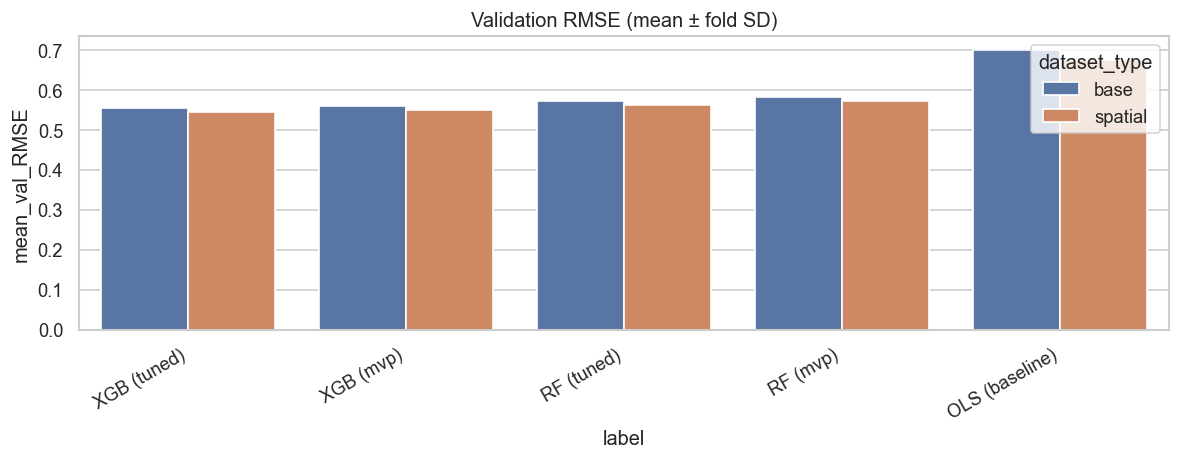

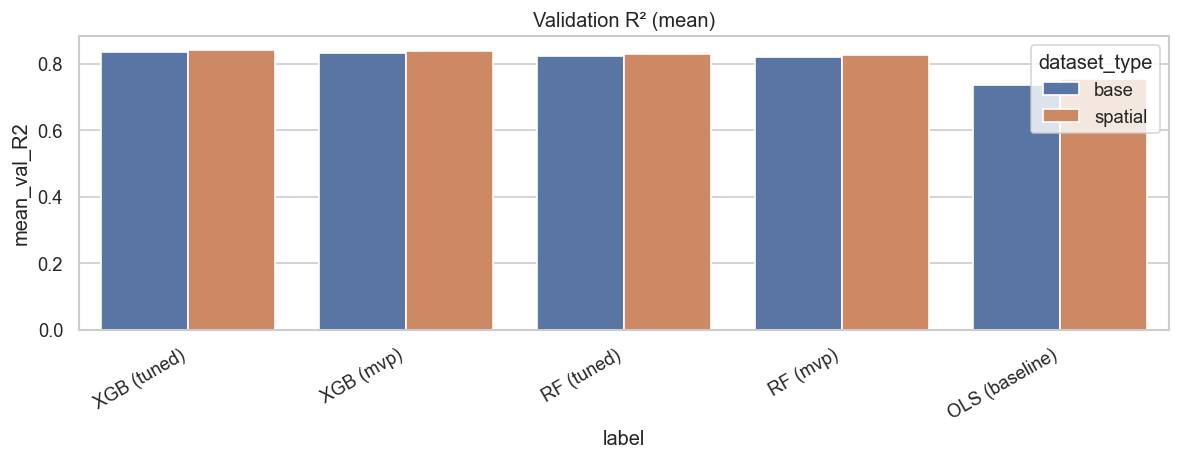

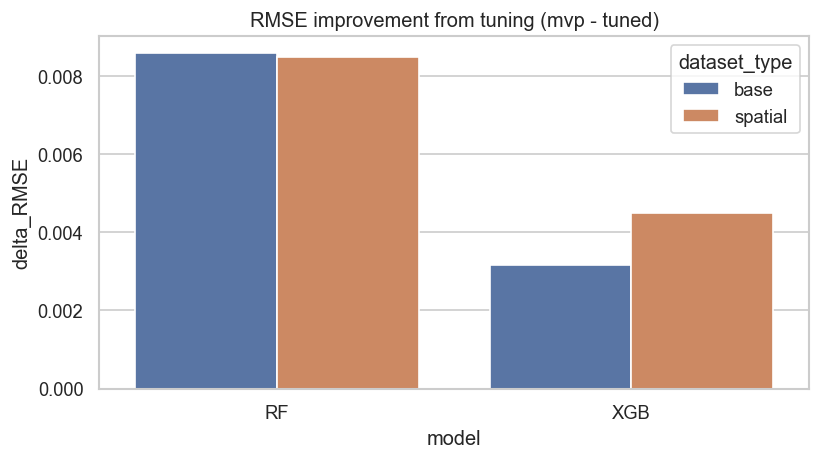

In [21]:
# 1) Comparison bar chart with error bars (RMSE)
plt.figure(figsize=(10,4))
plot_df = final_comparison.copy()
plot_df['label'] = plot_df['model'] + ' (' + plot_df['tuning_status'] + ')'

sns.barplot(data=plot_df, x='label', y='mean_val_RMSE', hue='dataset_type', errorbar=None)
# Add error bars manually
for i,row in plot_df.reset_index(drop=True).iterrows():
    pass
plt.title('Validation RMSE (mean ± fold SD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison_rmse.png')
plt.show()

# 2) R² chart
plt.figure(figsize=(10,4))
sns.barplot(data=plot_df, x='label', y='mean_val_R2', hue='dataset_type', errorbar=None)
plt.title('Validation R² (mean)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison_r2.png')
plt.show()

# 3) Untuned vs tuned improvement chart for RF and XGB
improv = final_comparison[final_comparison['model'].isin(['RF','XGB'])].copy()
# pivot
pivot = improv.pivot_table(index=['model','dataset_type'], columns='tuning_status', values='mean_val_RMSE')
pivot = pivot.reset_index()
pivot['delta_RMSE'] = pivot['mvp'] - pivot['tuned']
pivot.to_csv(OUT_DIR / 'untuned_vs_tuned_rmse_delta.csv', index=False)

plt.figure(figsize=(7,4))
sns.barplot(data=pivot, x='model', y='delta_RMSE', hue='dataset_type')
plt.title('RMSE improvement from tuning (mvp - tuned)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'untuned_vs_tuned_improvement.png')
plt.show()


## 16. Sprint 4 MVP conclusion


In [22]:
# Rule-based answers
best_rmse = final_comparison.sort_values('mean_val_RMSE').iloc[0]
best_r2 = final_comparison.sort_values('mean_val_R2', ascending=False).iloc[0]
most_stable = final_comparison.sort_values('std_val_RMSE').iloc[0]
most_overfit = final_comparison.sort_values('overfit_gap_RMSE', ascending=False).iloc[0]

print('Lowest mean val RMSE:', best_rmse[['model','dataset_type','tuning_status','mean_val_RMSE']].to_dict())
print('Highest mean val R2:', best_r2[['model','dataset_type','tuning_status','mean_val_R2']].to_dict())
print('Most stable (lowest std RMSE):', most_stable[['model','dataset_type','tuning_status','std_val_RMSE']].to_dict())
print('Largest overfit gap (RMSE):', most_overfit[['model','dataset_type','tuning_status','overfit_gap_RMSE']].to_dict())


Lowest mean val RMSE: {'model': 'XGB', 'dataset_type': 'spatial', 'tuning_status': 'tuned', 'mean_val_RMSE': 0.5449436516094363}
Highest mean val R2: {'model': 'XGB', 'dataset_type': 'spatial', 'tuning_status': 'tuned', 'mean_val_R2': 0.8403992562342554}
Most stable (lowest std RMSE): {'model': 'XGB', 'dataset_type': 'spatial', 'tuning_status': 'tuned', 'std_val_RMSE': 0.004216483901018741}
Largest overfit gap (RMSE): {'model': 'RF', 'dataset_type': 'base', 'tuning_status': 'tuned', 'overfit_gap_RMSE': 0.364179019841666}


## 17. Save outputs


In [23]:
# Save best-model error table
best_oof[['dataset_type','model','tuning_status','y_true','y_pred_oof','residual','abs_error'] + [c for c in ['gwb_code_10','gm_naam','population'] if c in best_oof.columns]] \
    .to_csv(OUT_DIR / 'error_analysis_best_model.csv', index=False)

print('Saved outputs to:', OUT_DIR)
print('Saved figures to:', FIG_DIR)


Saved outputs to: outputs/modeling_improvement
Saved figures to: outputs/modeling_improvement/figures


## Sprint 4 MVP answers

1. What changed since Sprint 3?
2. Why was RandomizedSearchCV used?
3. Did tuning improve model performance?
4. Are the models stable across folds?
5. Did spatial features improve performance?
6. Did overfitting improve or worsen?
7. Which model is currently leading?
8. What are the main error patterns?
9. Is the current model good enough for answering the research questions?
10. What should the next iteration focus on?

(Answer these using the generated `final_model_comparison.csv` and the diagnostic figures.)


## Methods/results draft text

### Methods paragraph draft

We compared a linear regression baseline with two tree-based regressors (random forest and XGBoost) using two feature sets: a non-spatial baseline dataset and a spatially-augmented dataset including exogenous queen-contiguity spillover features. Model selection and hyperparameter tuning were performed with 5-fold cross-validation, preferring grouped folds by municipality when available. To improve computational efficiency while exploring interacting hyperparameters, we used randomized hyperparameter search (`RandomizedSearchCV`) for both tree-based models with negative RMSE as the primary tuning objective. All preprocessing steps with leakage risk (median imputation and scaling for the linear baseline) were performed within scikit-learn pipelines and fit only on training folds. Performance was reported using RMSE, MAE, and R² on validation folds, alongside fold-level stability and train–validation gaps to assess overfitting. Error analysis was conducted using out-of-fold predictions, including residual diagnostics and stratified error summaries by target deciles and population/municipality groups.
